In [17]:
import pandas as pd 
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder, 
from sklearn.tree import DecisionTreeClassifier
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score


In [53]:
df = pd.read_csv("shop_smart_ecommerce.csv")
df.head()
# df.isnull().sum()
b=set(df["Revenue"])
b

{False, True}

In [38]:
df.head(10)

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.200000,0.200000,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.000000,0.100000,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.200000,0.200000,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.050000,0.140000,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.020000,0.050000,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False
5,0,0.0,0,0.0,19,154.216667,0.015789,0.024561,0.0,0.0,Feb,2,2,1,3,Returning_Visitor,False,False
6,0,0.0,0,0.0,1,0.000000,0.200000,0.200000,0.0,0.4,Feb,2,4,3,3,Returning_Visitor,False,False
7,1,0.0,0,0.0,0,0.000000,0.200000,0.200000,0.0,0.0,Feb,1,2,1,5,Returning_Visitor,True,False
8,0,0.0,0,0.0,2,37.000000,0.000000,0.100000,0.0,0.8,Feb,2,2,2,3,Returning_Visitor,False,False
9,0,0.0,0,0.0,3,738.000000,0.000000,0.022222,0.0,0.4,Feb,2,4,1,2,Returning_Visitor,False,False


In [75]:
le=LabelEncoder()
df["Month"]=le.fit_transform(df["Month"])
df["VisitorType"]=le.fit_transform(df["VisitorType"])
df["Weekend"]=le.fit_transform(df["Weekend"])
df["Revenue"]=le.fit_transform(df["Revenue"])

In [81]:
x=df.drop("Revenue",axis=1)
y=df["Revenue"]

In [89]:
x_train, x_test, y_train, y_test=train_test_split(x, y,test_size=0.2,random_state=42)

In [91]:
model=DecisionTreeClassifier()

model.fit(x_train,y_train)

DecisionTreeClassifier()

In [94]:
from sklearn.metrics import accuracy_score

y_pred=model.predict(x_test)

print("Accuracy:",accuracy_score(y_test,y_pred))

Accuracy: 0.8613138686131386


In [105]:
from sklearn.tree import plot_tree

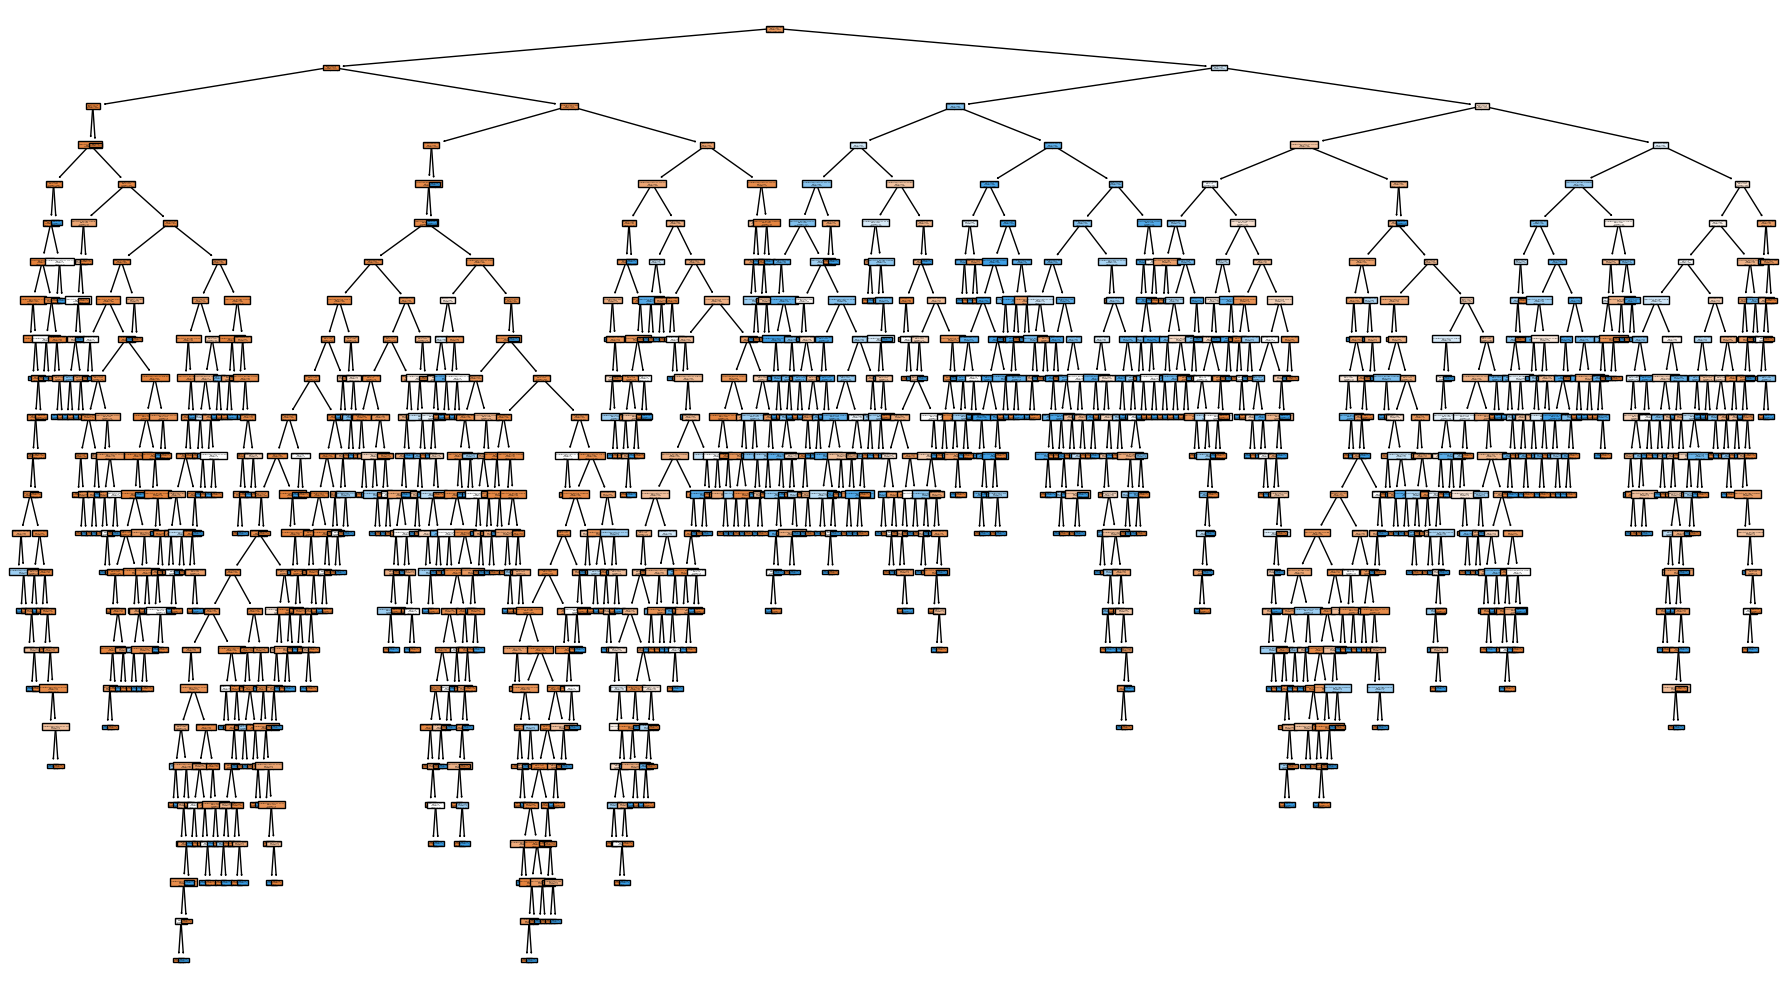

In [115]:
plt.figure(figsize=(18, 10))
plot_tree(
    model,
    feature_names=x.columns,
    filled=True,
)

plt.tight_layout()
plt.show()

# pre-purring

for depth=2, accuracy=0.8763179237631792
for depth=3, accuracy=0.8868613138686131
for depth=4, accuracy=0.8884833738848338
for depth=5, accuracy=0.884022708840227
for depth=6, accuracy=0.8864557988645579
for depth=7, accuracy=0.8876723438767234
for depth=8, accuracy=0.889294403892944


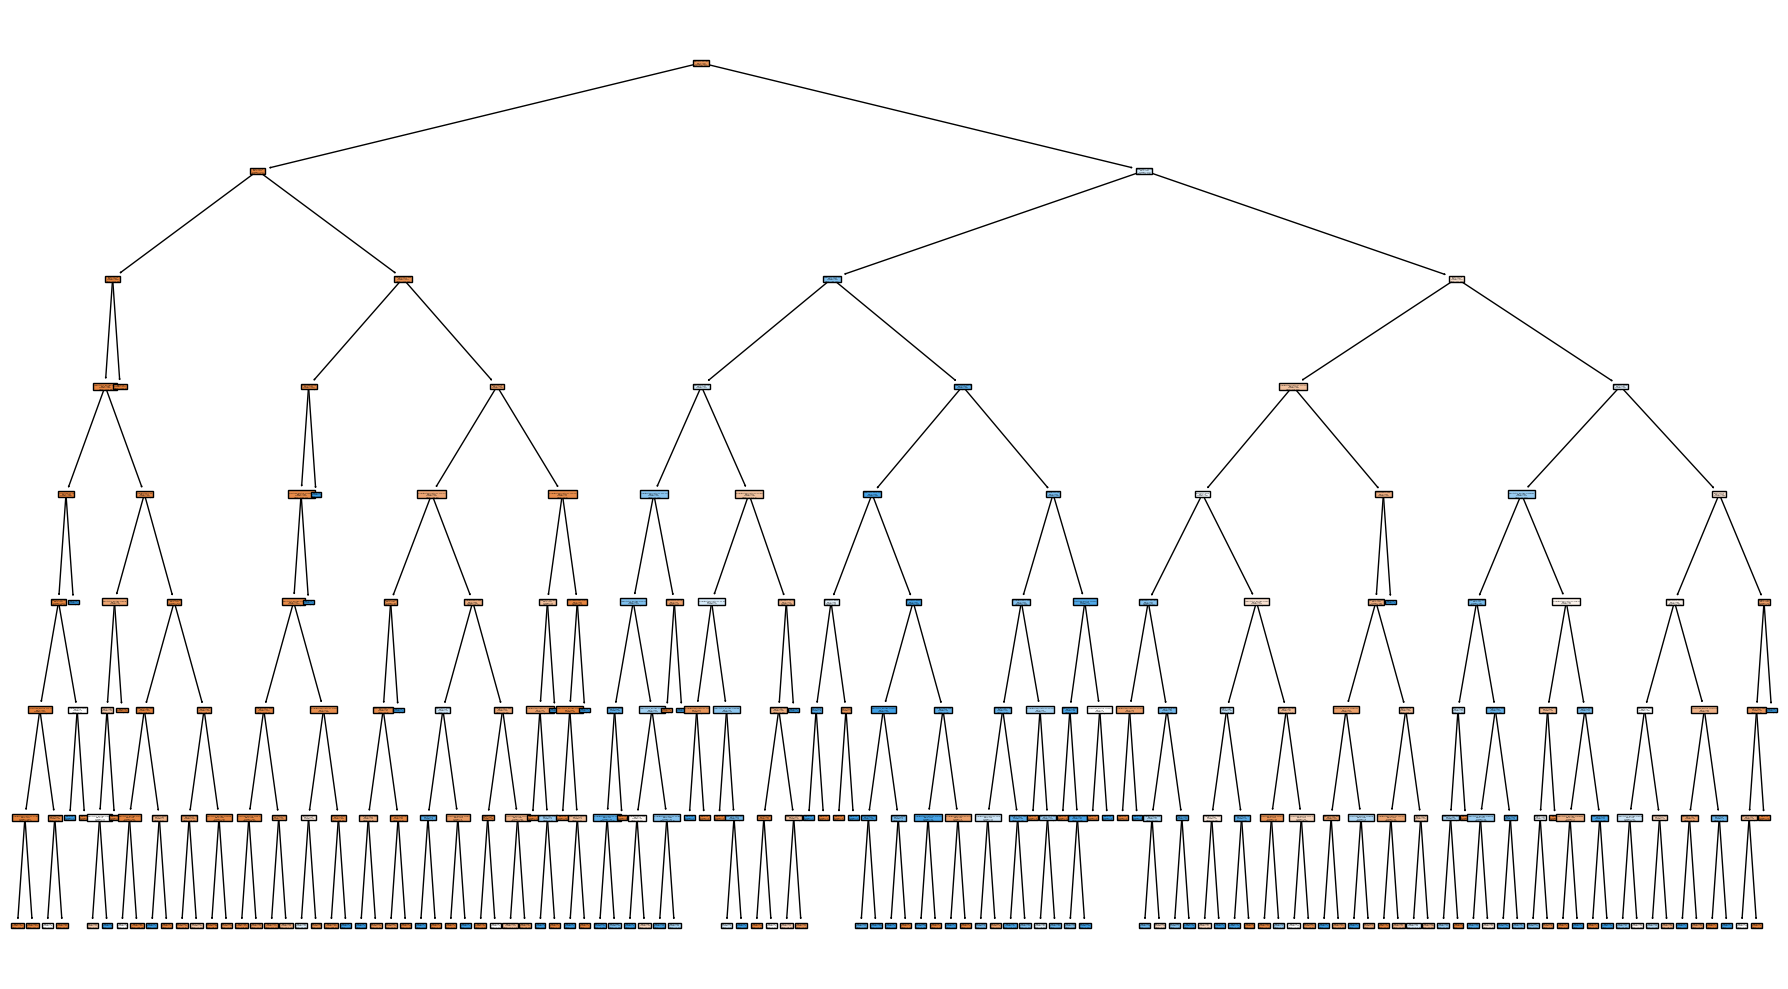

for depth=9, accuracy=0.8832116788321168
for depth=10, accuracy=0.8771289537712895


In [126]:
max_depths = [2, 3, 4, 5, 6, 7, 8, 9, 10]

for depth in max_depths:
    model = DecisionTreeClassifier(max_depth=depth)
    model.fit(x_train, y_train)

    acc = model.score(x_test, y_test)
    print(f"for depth={depth}, accuracy={acc}")

    if depth==8:
        plt.figure(figsize=(18, 10))
        plot_tree(
            model,
            feature_names=x.columns,
            filled=True
        )
        
        plt.tight_layout()
        plt.show()


for sample split=5, accuracy=0.8884833738848338
for sample split=10, accuracy=0.8884833738848338


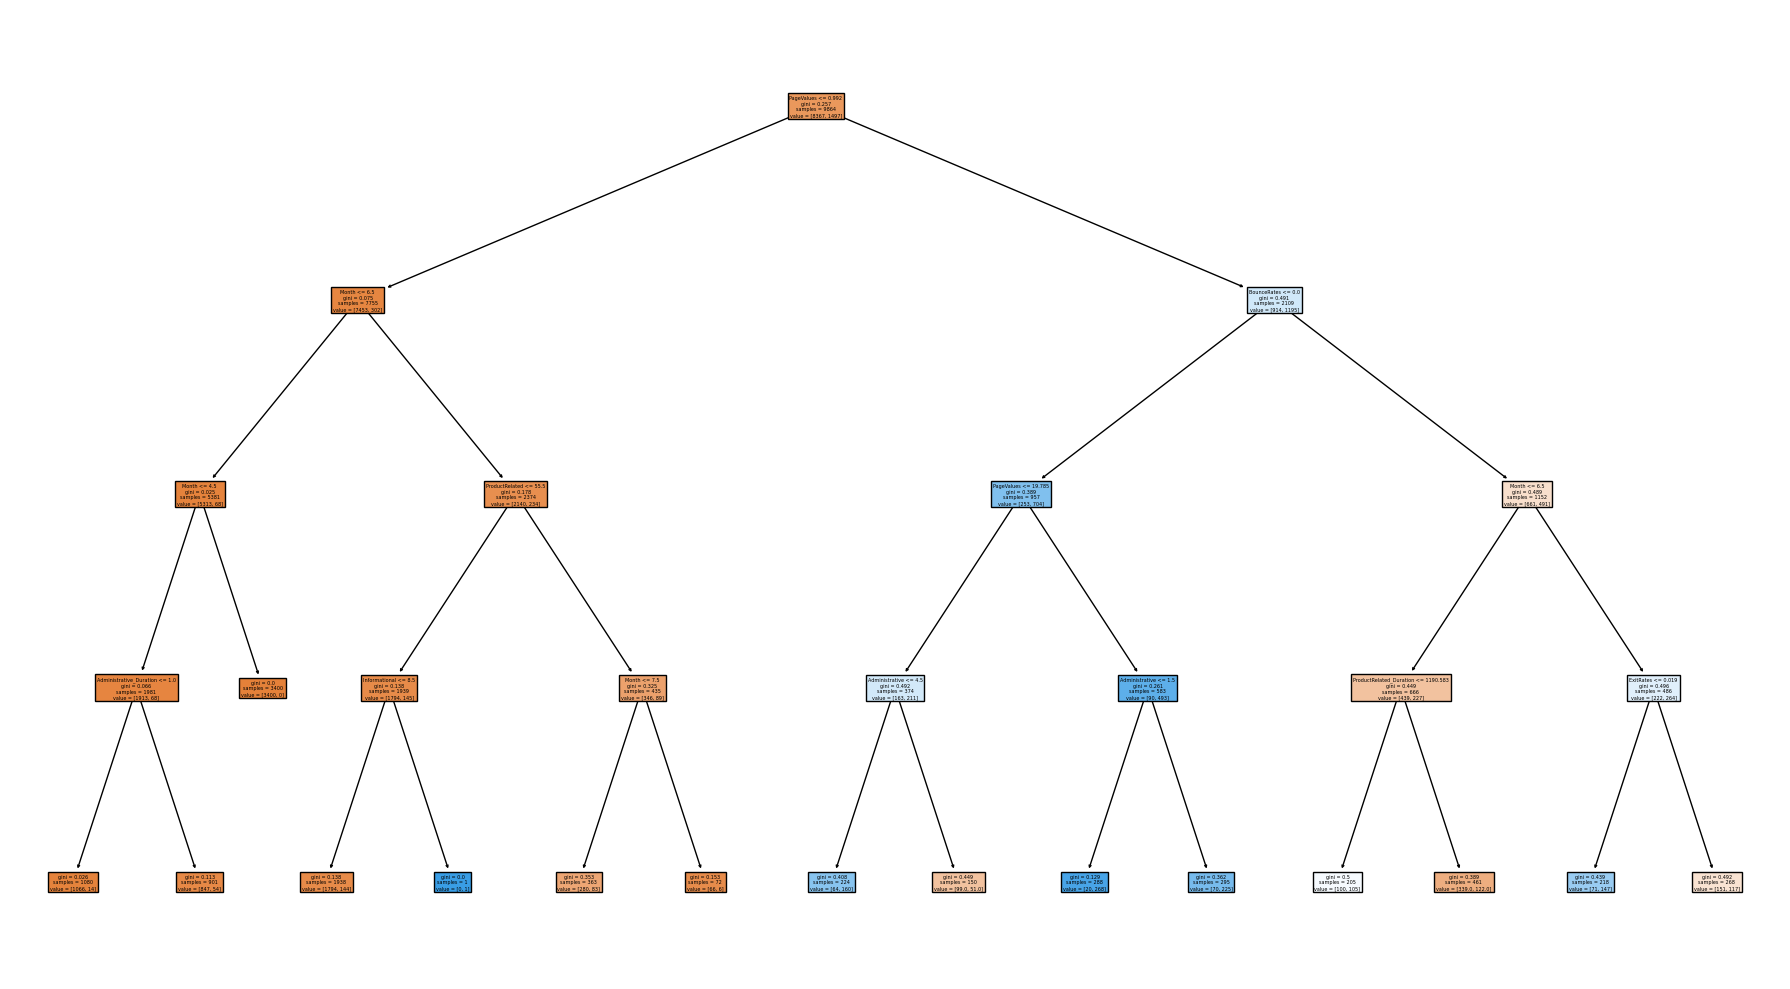

for sample split=15, accuracy=0.8884833738848338
for sample split=20, accuracy=0.8884833738848338
for sample split=25, accuracy=0.8884833738848338
for sample split=30, accuracy=0.8884833738848338


In [124]:
min_samples_splits = [5, 10, 15, 20, 25, 30]

for split in min_samples_splits:
    model = DecisionTreeClassifier(max_depth=4, min_samples_split=split)
    model.fit(x_train, y_train)

    acc = model.score(x_test, y_test)
    print(f"for sample split={split}, accuracy={acc}")

    if split==10:
        plt.figure(figsize=(18, 10))
        plot_tree(
            model,
            feature_names=x.columns,
            filled=True
        )
        
        plt.tight_layout()
        plt.show()